GULPS (Global Unitary Linear Programming Synthesis) compiles arbitrary two-qubit unitaries into non-standard instruction sets. It combines linear programming with lightweight numerics to handle fractional, continuous, or heterogeneous gate sets — anything beyond what analytical decomposition rules cover.

In [ ]:
!pip install gulps[dev] -q

Define your instruction set as a `DiscreteISA` - a list of gates with associated costs and names.

In [1]:
from qiskit.circuit.library import iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary

from gulps import GulpsDecomposer
from gulps.core.isa import DiscreteISA

isa = DiscreteISA(
    gate_set=[
        iSwapGate().power(1.0),
        iSwapGate().power(1 / 2),
        iSwapGate().power(1 / 3),
    ],
    costs=[1.0, 1 / 2, 1 / 3],
    names=["iswap", "sqrt2iswap", "sqrt3iswap"],
)
decomposer = GulpsDecomposer(isa=isa)

Pass any 4×4 unitary (Qiskit `Gate` or `np.ndarray`) and get back a `QuantumCircuit`.

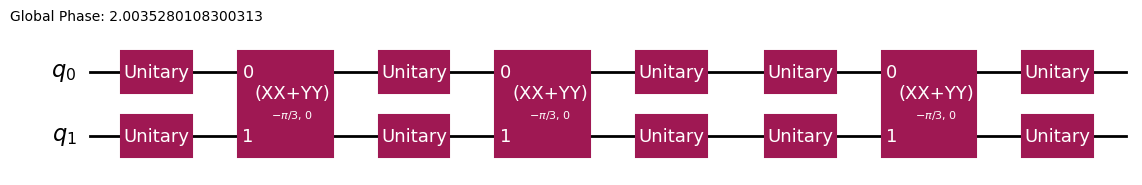

In [2]:
u = random_unitary(4, seed=0)
circuit = decomposer(u)
circuit.draw("mpl")

In [3]:
fid = average_gate_fidelity(u, Operator(circuit))
print(f"Fidelity: {fid:.12f}")

Fidelity: 1.000000000000


To compile a full multi-qubit circuit, use `GulpsDecompositionPass` as a Qiskit `TransformationPass`. GULPS leaves single-qubit gates unsimplified, so appending `Optimize1qGatesDecomposition` is recommended.

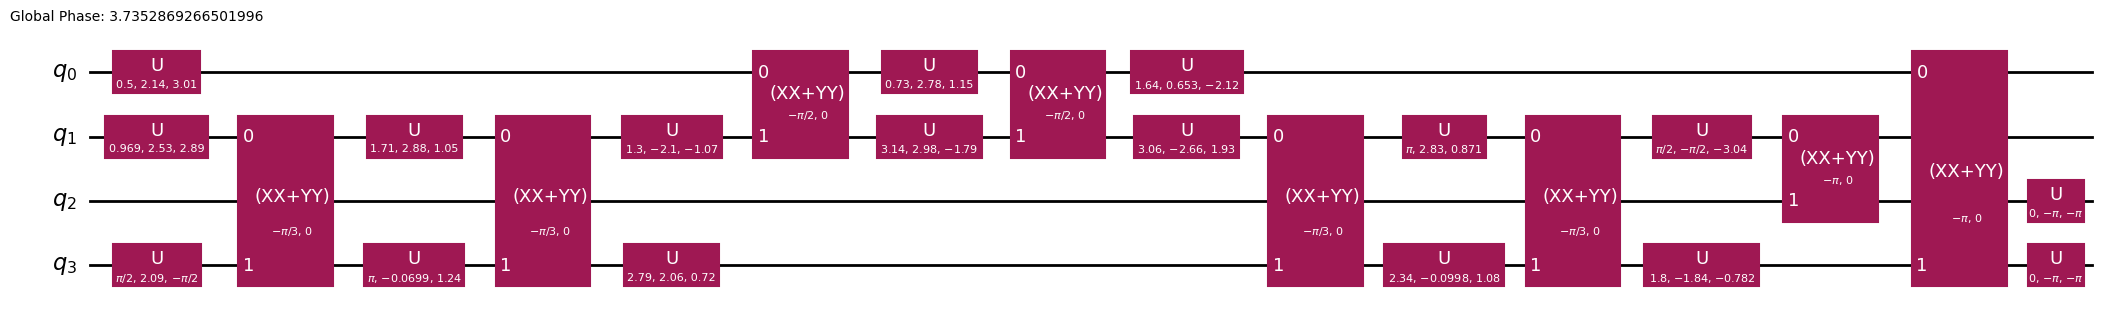

In [4]:
from gulps import GulpsDecompositionPass
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from qiskit.circuit.random import random_circuit

gulps_pm = PassManager(
    [
        GulpsDecompositionPass(decomposer),
        Optimize1qGatesDecomposition(basis="u3"),
    ]
)

input_qc = random_circuit(4, 4, max_operands=2, seed=0)
output_qc = gulps_pm.run(input_qc)
output_qc.draw("mpl", fold=-1)

GULPS also registers as a Qiskit transpiler plugin. If the instruction set is specified in a Qiskit `Target`, you can call `transpile()` directly.

In [5]:
from qiskit.transpiler.preset_passmanagers.plugin import list_stage_plugins

list_stage_plugins("translation")

['default', 'synthesis', 'translator', 'gulps']

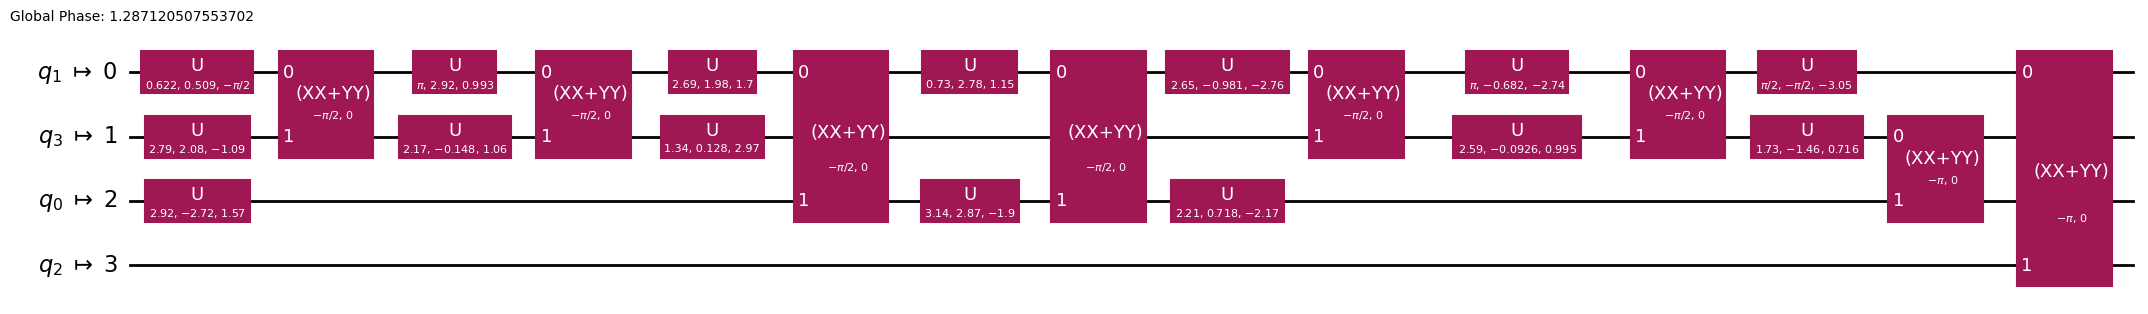

In [6]:
from qiskit import transpile
from gulps.comparisons.isa_library.example_target import mock_iswap_family_target

output_qc = transpile(
    input_qc, target=mock_iswap_family_target, translation_method="gulps"
)
output_qc.draw("mpl", fold=-1)